### **4. PATSTĀVĪGAIS DARBS. Regresija**

# Nepārtrauktas vērtības prognozēšana, vizualizācija un kļūdu metrikas

## 1. uzdevums. Sagatavo datus regresijai

### 1.1. Ielādē datu kopu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ielādē 2. nedēļā sagatavoto tīro datu kopu
df = pd.read_csv('../week2/shoppers_clean.csv')
print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")


Datu kopa: 12330 rindas, 30 kolonnas


### 1.2. Izvēlies target un features

PageValues statistika:
count    12330.000000
mean         5.889258
std         18.568437
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        361.763742
Name: PageValues, dtype: float64


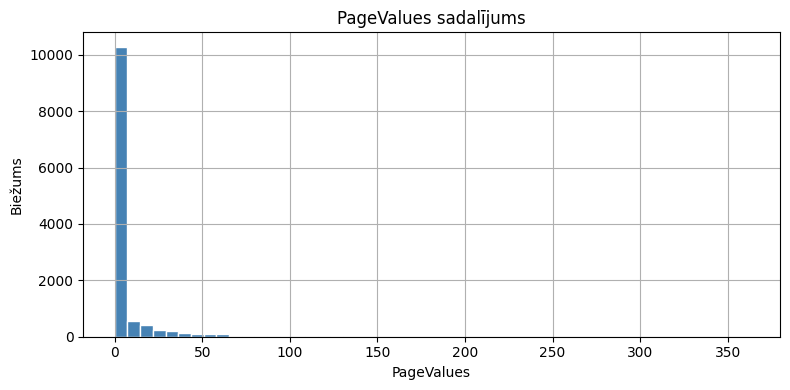

In [2]:
# Apskatām target mainīgo
print("PageValues statistika:")
print(df['PageValues'].describe())

plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues sadalījums')
plt.xlabel('PageValues')
plt.ylabel('Biežums')
plt.tight_layout()
plt.show()

### 1.3. Sagatavo X un y

In [3]:
# Target
y = df['PageValues']

# Features — visas kolonnas, izņemot PageValues un Revenue
# (Revenue nedrīkst izmantot, jo tā ir "nākotnes" informācija — data leakage!)
X = df.drop(['PageValues', 'Revenue'], axis=1)

# (PASKAIDROJUMS) Kāpēc izņemam 'Revenue' no X?
# 'Revenue' ir pirkuma fakts (0/1), kas ir zināms tikai sesijas beigās.
# Ja to izmantotu kā ievades pazīmi, modelis izmantotu nākotnes informāciju (data leakage)
# un rādītu mākslīgi labas metrikas, bet reālā prognozēšanas brīdī šis lauks nav pieejams.

print(f"Features skaits: {X.shape[1]}")
print(f"Target: PageValues")

Features skaits: 28
Target: PageValues


### 1.4. Treniņa/testa sadalījums

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Treniņa kopa: {X_train.shape[0]} rindas")
print(f"Testa kopa: {X_test.shape[0]} rindas")

Treniņa kopa: 9864 rindas
Testa kopa: 2466 rindas


## 2. uzdevums. Uztrenē lineārās regresijas modeli

### 2.1. Modeļa trenēšana

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Izveido un uztrenē modeli
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prognozes
y_pred = lr_model.predict(X_test)

# Metrikas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Lineārā regresija: rezultāti ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

=== Lineārā regresija: rezultāti ===
MSE:  338.5721
RMSE: 18.4003
MAE:  9.2073
R²:   0.0524


### 2.2.  Metriku interpretācijas

MSE (Mean Squared Error): vidējā kvadrātiskā kļūda — kvadrāts vairāk soda lielas kļūdas.
RMSE (Root MSE): MSE sakne — kļūda tajās pašās vienībās kā PageValues, tāpēc vieglāk interpretēt.
MAE (Mean Absolute Error): vidējā absolūtā kļūda — robustāka pret ekstrēmiem outlier nekā MSE/RMSE.
R²: skaidrotās dispersijas īpatsvars (1=perfekti; 0=~tikpat labi kā minēt vidējo; <0=sliktāk).

*Ko nozīmē rezultāti?*

 - Zems R² nozīmē, ka modelis skaidro tikai nelielu daļu no PageValues variācijas.
 - PageValues sadalījums ir ļoti asimetrisks (daudz 0; daži ļoti lieli maksimumi),
   tāpēc lineārs modelis bieži nespēj 'noķert' lielās vērtības un kļūda pieaug.
 - Praktiska ideja uzlabojumiem: feature engineering un/vai mērķa transformācija (piem., log(1+PageValues)).

## 3. uzdevums. Vizualizē prognozes

### 3.1. Faktiskās vs. prognozētās vērtības

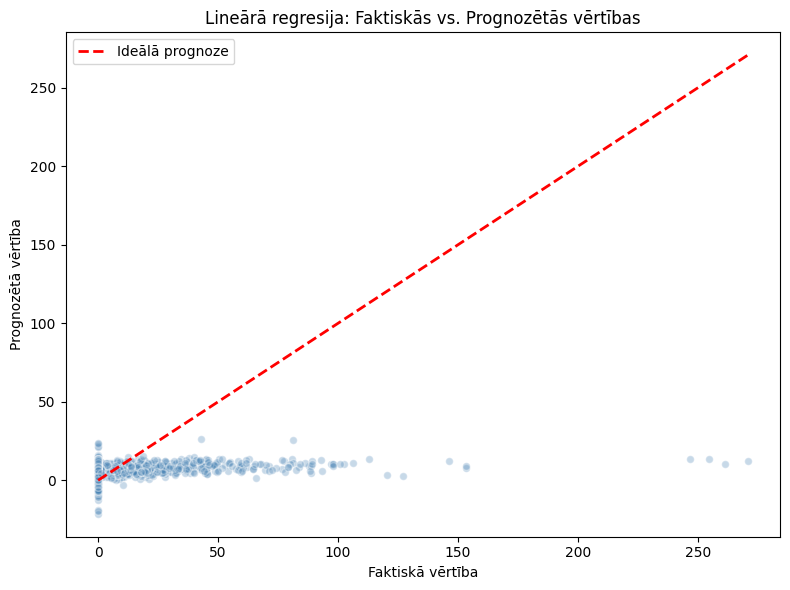

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=30)
# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test.max(), y_pred.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineārā regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.tight_layout()
plt.show()

## 3.2. Atlikumu (residuals) analīze

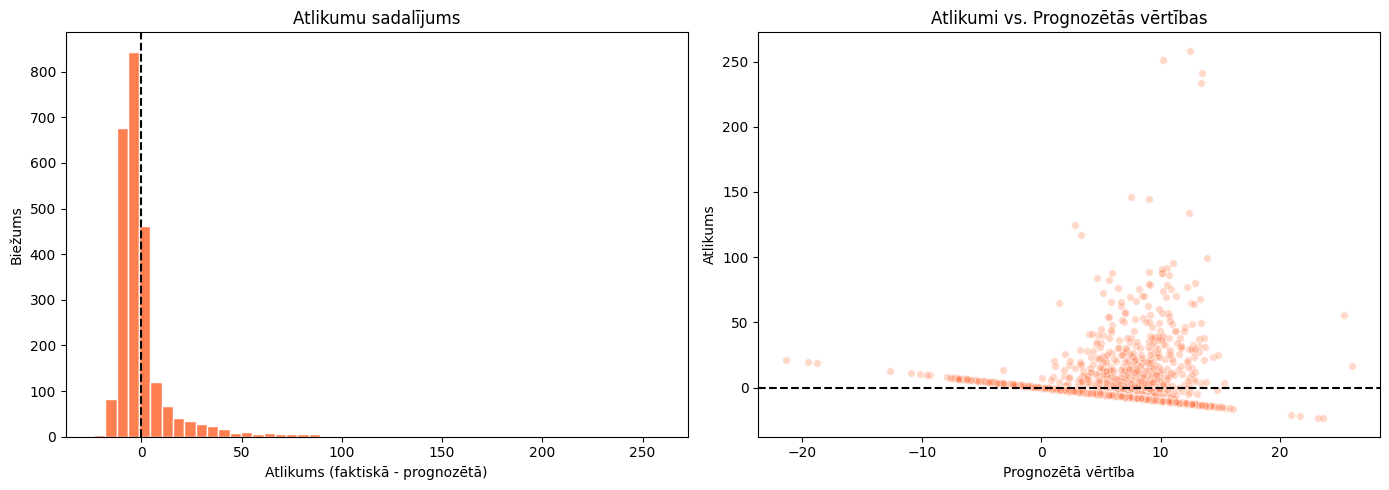

In [7]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

### 3.3. Vizualizāciju interpretācijas

1. Faktiskā vs prognozētā: jo tuvāk punkti ideālajai līnijai, jo precīzāka prognoze.
Ja redzama liela izkliede, modelis sistemātiski kļūdās vai neietver nelineāras sakarības.

2. Atlikumi (residuals): ideāli atlikumi ir ap 0 bez struktūras.
     - 'Piltuve' (izkliede palielinās) → heteroscedastiskums (kļūdas nav vienādas visā diapazonā).
     - Trends (piem., atlikumi pārsvarā pozitīvi pie lielām vērtībām) → nelinearitāte/feature trūkums.
     - Spēcīgi outlier histogrammā → datu asimetrija, kas var prasīt transformāciju vai robustākus modeļus. 

## 4. uzdevums. Uzlabo modeli

### 4.1. Cits regresijas modelis

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

# Metrikas
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("=== Random Forest Regressor: rezultāti ===")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

=== Random Forest Regressor: rezultāti ===
RMSE: 18.1639
R²:   0.0766


In [9]:
### 4.2. Salīdzinājuma tabula

In [10]:
comparison = pd.DataFrame({
    'Modelis': ['Lineārā regresija', 'Random Forest'],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})

print(comparison.to_string(index=False))

          Modelis      RMSE       R²
Lineārā regresija 18.400330 0.052425
    Random Forest 18.163917 0.076618


In [11]:
### 4.3. Vizuāls salīdzinājums

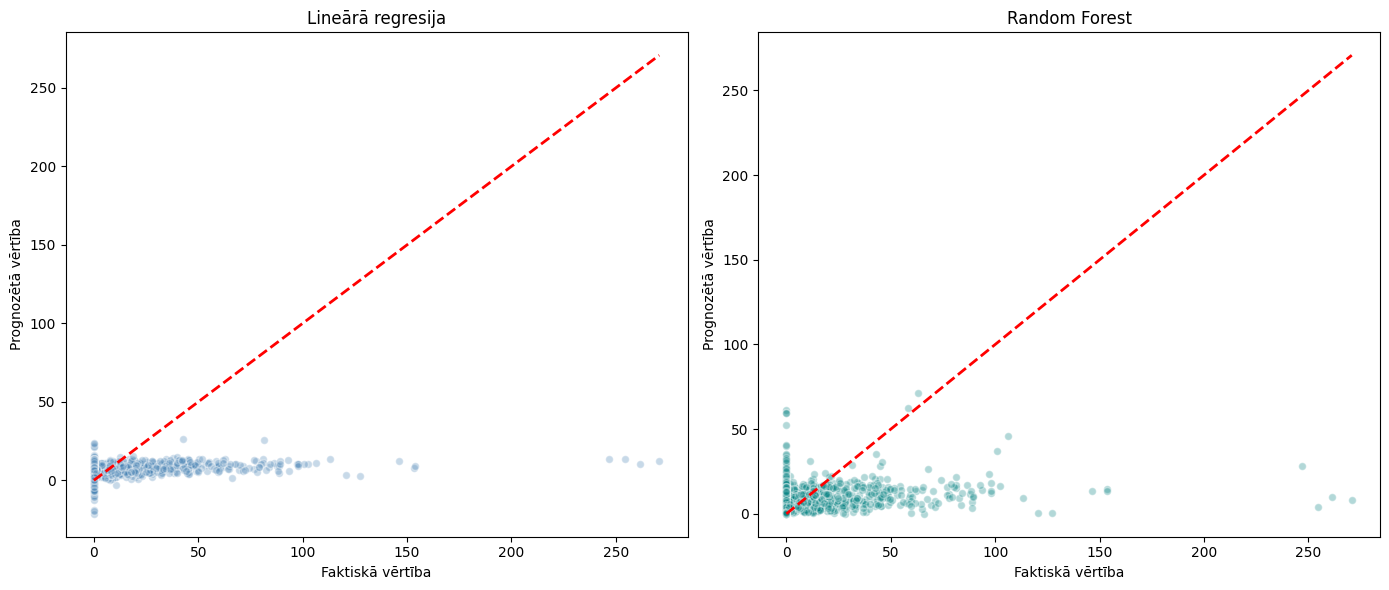

In [12]:
# (LABOJUMS) Max vērtība ideālajai līnijai: ņemam vērā abus modeļus
max_val = max(y_test.max(), y_pred.max(), y_pred_rf.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, title, color in [
    (axes[0], y_pred, 'Lineārā regresija', 'steelblue'),
    (axes[1], y_pred_rf, 'Random Forest', 'teal')
]:
    ax.scatter(y_test, pred, alpha=0.3, color=color, edgecolors='white', s=30)
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
    ax.set_xlabel('Faktiskā vērtība')
    ax.set_ylabel('Prognozētā vērtība')
    ax.set_title(title)

plt.tight_layout()
plt.show()

### 4.4. Secinājumi

Modeļus salīdzinām pēc RMSE un R²: mazāks RMSE un lielāks R² nozīmē labāku prognozi.
Random Forest parasti uzrāda nedaudz labāku rezultātu nekā lineārā regresija, jo spēj modelēt nelinearitātes.
Abiem modeļiem R² ir zems → ar pašreizējiem feature modelis skaidro maz; PageValues ir asimetrisks un grūti prognozējams.
Ko darītu tālāk: (1) feature engineering, (2) hiperparametru tuning, (3) mērķa transformācija (log1p),
(4) modeļi kā Gradient Boosting/XGBoost (ja kursā atļauts).

Biznesā: PageValues prognozi var izmantot, lai prioritizētu sesijas/lietotājus (top segmentam),
bet pirms reālas lietošanas jāuzlabo precizitāte un jāpārbauda ar cross-validation.

Praktiski par skaitļiem: Lineārajai regresijai RMSE ≈ 18.40 un R² ≈ 0.052, bet Random Forest RMSE ≈ 18.16 un R² ≈ 0.077,
tātad RF kļūdās vidēji par ~0.24 PageValues vienībām mazāk un izskaidro nedaudz vairāk variācijas, tomēr kopējā skaidrošanas spēja ir zema.
Tas nozīmē, ka prognozes var būt noderīgas aptuvenai sesiju prioritizēšanai (piem., top vs pārējie), bet nav pietiekami precīzas,
lai paļautos uz tām individuālā līmenī bez papildu uzlabojumiem.

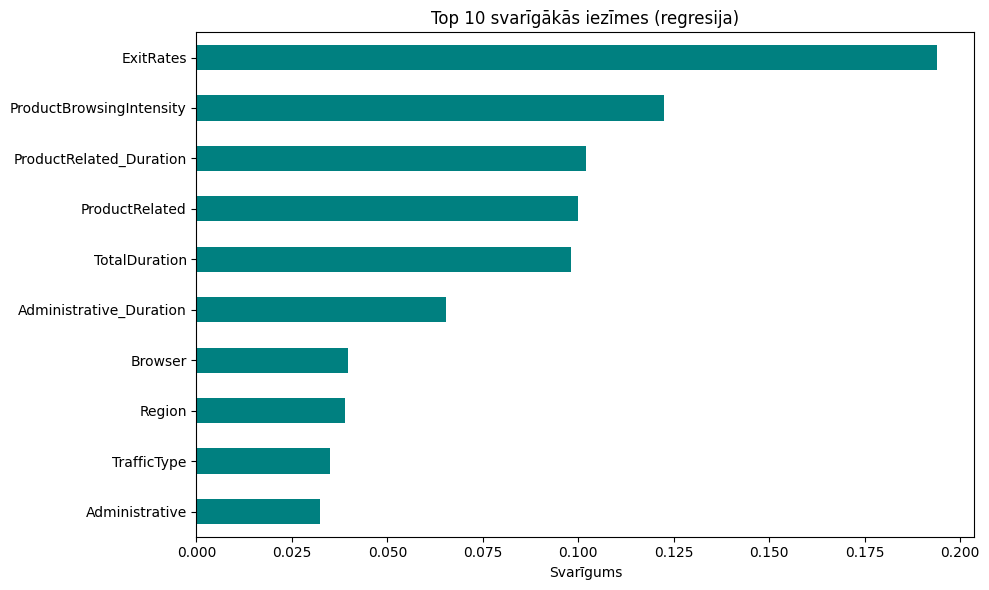

In [13]:
# Feature importance
importances = rf_reg.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 svarīgākās iezīmes (regresija)')
plt.xlabel('Svarīgums')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. uzdevums. Gala projekta plāns

### 5.1. Projekta plāns

**Mans gala projekts - Adult (Census Income)**

**1. Problēma**

Prognozēt personas ienākumu klasi no pazīmēm (demogrāfija/izglītība/nodarbinātība): vai `income` ir `<=50K` vai `>50K`.
(Piezīme: vēl precizēšu gala lietojuma scenāriju — ko nozīmē “labs” modelis praksē.)

**2. Datu kopa**

Adult (Census Income) datu kopa `adult.csv` (tabulāri dati) ar mērķa mainīgo `income` un pazīmēm, piemēram, `age`,
 `education`, `workclass`, `hours.per.week`, `capital.gain/loss`, u.c.
 Datu kopā ir gan skaitliskās, gan kategoriskās pazīmes, tāpēc var veidot pilnvērtīgu klasifikācijas modeli (nav jāmeklē cita datu kopa).

**3. ML pieeja**

Klasifikācija, jo `income` ir bināra klase (`<=50K` / `>50K`).
Izvēlēšos šo pieeju, jo mērķis ir paredzēt kategoriju, nevis nepārtrauktu skaitli.

**4. Plānotās metrikas**
 - F1 (īpaši klasei `>50K`), jo klasifikācijā bieži svarīgi sabalansēt precision un recall (un klases var būt nesabalansētas).
 - Precision/Recall, lai saprastu kļūdu veidus un cik labi atpazīstu `>50K`.
 - Confusion matrix, lai vizuāli redzētu kļūdas starp klasēm.
 - (TODO) ROC-AUC vai PR-AUC — ja būs vajadzīgs papildu salīdzinājums starp modeļiem.

**5. Datu sagatavošana**
 - Pārbaudīšu trūkstošās vērtības: Adult datu kopā mēdz būt “?” kategoriskajās kolonnās (piem., `workclass`, `occupation`, `native.country`),
   un tās jāapstrādā pirms modelēšanas.
 - Kategoriskās pazīmes kodēšu ar One-Hot Encoding; skaitliskās (piem., `age`, `hours.per.week`, `capital.gain/loss`) mērogošu, ja tas uzlabo modeļa darbu.
 - Sadalīšu datus train/test un izmantošu cross-validation stabilākam novērtējumam.# - Izmantosšu `Pipeline`/`ColumnTransformer`, lai priekšapstrāde (kodēšana + mērogošana) un modelis būtu vienā reproducējamā procesā.
 - (TODO) Feature engineering: apvienot retas kategorijas (piem., `native.country`) un pārbaudīt, vai tas uzlabo F1/Recall.

**6. Plānotie modeļi**
 - Baseline: Logistic Regression (ātrs, interpretējams salīdzinājums).
 - Random Forest (nelineārs modelis ar iespēju iegūt feature importance).
 - (TODO) Hiperparametru tunešana (GridSearch/RandomSearch) un, ja vajag, sliekšņa pielāgošana, lai uzlabotu `>50K` klases recall/F1.

 ### 5.2. Pašnovērtējums 

**Vai mana problēma ir skaidri definēta un atbildama ar ML?**

Jā — mērķis ir paredzēt bināru mērķa mainīgo `income` (klase `<=50K` vai `>50K`), un to var risināt ar klasifikācijas ML metodēm.
(Melnraksts: vēl precizēšu gala lietojuma scenāriju un to, kurš kļūdu veids ir kritiskāks.)

**Vai man ir piemērota datu kopa?**

Jā — Adult (Census Income) `adult.csv` satur gan mērķa mainīgo `income`, gan daudz dažādu pazīmju (skaitliskas un kategoriskas),
kas ir pietiekamas sakarīga modeļa izveidei, tāpēc nav jāmeklē cita datu kopa.
(Melnraksts: vēl pabeigšu trūkstošo/nekorektu vērtību (“?”) apstrādes izvērtējumu.)

**Vai es zinu, kādu metriku izmantošu un kāpēc?**

Jā — izmantošu F1, Precision/Recall un confusion matrix, jo tās ļauj novērtēt bināru klasifikāciju arī gadījumā, ja klases ir nesabalansētas,
un palīdz saprast kļūdu veidus starp klasēm.
(Melnraksts: ja būs nepieciešams, pievienošu arī ROC-AUC vai PR-AUC papildu salīdzināšanai.)
